Import Required Libraries

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as Estimator
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager

Build a Simple Quantum Circuit

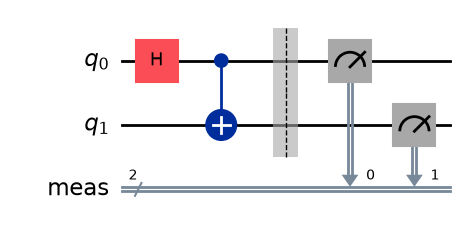

In [2]:
# Create a 2-qubit circuit
qc = QuantumCircuit(2)

# Prepare Bell state: |00> + |11> / sqrt(2)
qc.h(0)
qc.cx(0, 1)

# Measure all qubits
qc.measure_all()

# Display the circuit
qc.draw('mpl')

Run the Circuit on AerSimulator

In [3]:
# Initialize simulator
simulator = AerSimulator()

# Transpile the circuit for the simulator
qc_transpiled = transpile(qc, simulator)

# Run with 1024 shots
result = simulator.run(qc_transpiled, shots=1024).result()

# Get measurement counts
counts = result.get_counts()
print("Measurement counts:")
print(counts)

Measurement counts:
{'11': 520, '00': 504}


Compute Expectation Value Manually

In [4]:
# Total shots
total_shots = sum(counts.values())

# Expectation value of Z⊗Z
expectation = 0
for state, count in counts.items():
    # Count +1 for '00' and '11', -1 for '01' and '10'
    if state in ['00', '11']:
        expectation += count
    else:
        expectation -= count

expectation_value = expectation / total_shots
print(f"Manual expectation value <Z⊗Z> = {expectation_value:.4f}")

Manual expectation value <Z⊗Z> = 1.0000


Compute Expectation Value Using Estimator

In [5]:
# Define the observable Z⊗Z
observable = SparsePauliOp("ZZ")

# Create an Estimator instance
estimator = Estimator()

# Transpile circuit for the simulator target
pass_manager = generate_preset_pass_manager(3, AerSimulator())
isa_circuit = pass_manager.run(qc)

# Run the estimator
pub = (isa_circuit, observable)
job = estimator.run([pub])
result = job.result()

# Extract the expectation value
pub_result = result[0]
est_value = float(pub_result.data.evs)
print(f"Estimator expectation value <Z⊗Z> = {est_value:.4f}")

Estimator expectation value <Z⊗Z> = 1.0000


Visualizing the Results

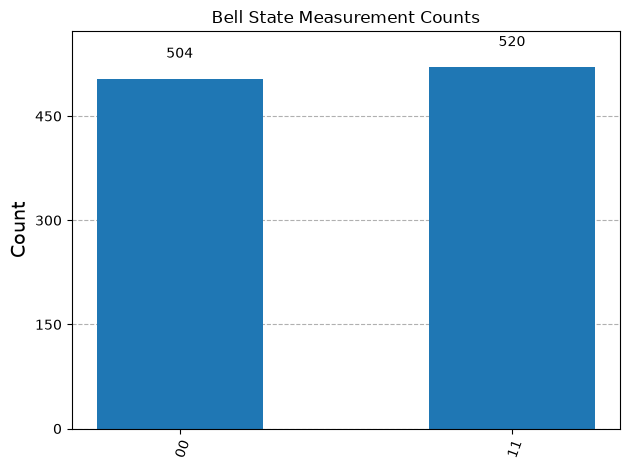

In [6]:
from qiskit.visualization import plot_histogram

plot_histogram(counts, title='Bell State Measurement Counts')

Complete Code

Manual <Z⊗Z> = 1.0000
Estimator <Z⊗Z> = 1.0000


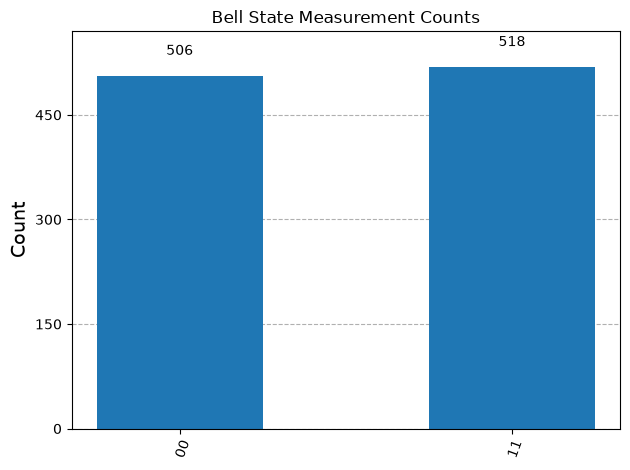

In [7]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as Estimator
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram

# 1. Build circuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

# 2. Run on AerSimulator
simulator = AerSimulator()
qc_transpiled = transpile(qc, simulator)
result = simulator.run(qc_transpiled, shots=1024).result()
counts = result.get_counts()

# 3. Manual expectation value
total_shots = sum(counts.values())
expectation = 0
for state, count in counts.items():
    if state in ['00', '11']:
        expectation += count
    else:
        expectation -= count
manual_value = expectation / total_shots
print(f"Manual <Z⊗Z> = {manual_value:.4f}")

# 4. Estimator expectation value
observable = SparsePauliOp("ZZ")
estimator = Estimator()
pass_manager = generate_preset_pass_manager(3, AerSimulator())
isa_circuit = pass_manager.run(qc)
job = estimator.run([(isa_circuit, observable)])
result_est = job.result()
est_value = float(result_est[0].data.evs)
print(f"Estimator <Z⊗Z> = {est_value:.4f}")

# 5. Visualize
plot_histogram(counts, title='Bell State Measurement Counts')